# SMS Spam Filter Case Study

This notebook documents the full CRISP-DM workflow used to build a binary
SMS spam classifier with adjustable risk levels. It reproduces the figures,
tables and model outputs used in the analysis. Random seed is fixed (`42`) so
that results are deterministic.

**Workflow**

1. Business and data understanding
2. Data quality assessment and EDA
3. Text cleaning and train/test split
4. Three candidate models (Multinomial Naive Bayes, Logistic Regression, Linear SVM)
5. Cross-validation and test-set evaluation
6. Confusion matrix, threshold sweep, risk levels
7. Error analysis (false positives / false negatives)
8. Saved artefacts for reproducibility and simple inference


## 1. Setup

In [1]:
import json, re, string, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
ROOT = Path.cwd().parent
print("Project root:", ROOT)

Project root: /app/spam-filter-case-study


## 2. Business and data understanding

The company plans to open a public short-message channel for customer feedback. The service team needs a filter that:

- correctly distinguishes spam from legitimate (ham) messages,
- supports adjustable risk levels (strict / balanced / permissive),
- is explainable enough for non-technical stakeholders, and
- supports a feedback loop for future retraining.

The dataset is the UCI *SMS Spam Collection v.1* (Almeida & Hidalgo, 2011), containing 5,574 English SMS messages tagged as `ham` or `spam`.

## 3. Load and inspect the data

In [2]:
df = pd.read_csv(ROOT / "data/raw/SMSSpamCollection.csv",
                 sep="\t", header=None, names=["label", "message"],
                 encoding="utf-8")
df["length"] = df["message"].str.len()
print("Shape:", df.shape)
print(df.head())
print("\nNulls:", df.isnull().sum().to_dict())
print("Duplicates:", int(df.duplicated().sum()))
print("\nClass distribution:\n", df['label'].value_counts())

Shape: (5572, 3)
  label                                            message  length
0   ham  Go until jurong point, crazy.. Available only ...     111
1   ham                      Ok lar... Joking wif u oni...      29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155
3   ham  U dun say so early hor... U c already then say...      49
4   ham  Nah I don't think he goes to usf, he lives aro...      61

Nulls: {'label': 0, 'message': 0, 'length': 0}
Duplicates: 403

Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


### 3.1 Drop duplicates

About 7% of the rows are exact duplicates. They are removed to avoid leaking identical text into both the training and test partitions.

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
print("After dedup:", df.shape)
print(df.groupby('label')['length'].agg(['mean','median','max']).round(1))

After dedup: (5169, 3)
        mean  median  max
label                    
ham     70.9    53.0  910
spam   137.7   148.0  223


### 3.2 Class distribution and message length

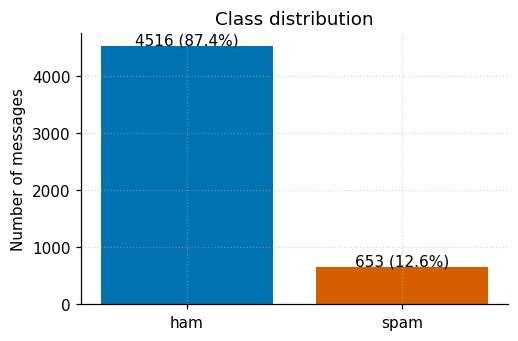

In [4]:
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True,
                     'grid.linestyle': ':', 'grid.alpha': 0.5,
                     'axes.spines.top': False, 'axes.spines.right': False})
GREY_DARK, GREY_MID, GREY_LIGHT = '#0072B2', '#D55E00', '#56B4E9'
ACCENT_GREEN = '#009E73'

counts = df['label'].value_counts()
fig, ax = plt.subplots(figsize=(5,3.2))
ax.bar(counts.index, counts.values, color=[GREY_DARK, GREY_MID])
for i,v in enumerate(counts.values):
    ax.text(i, v+30, f'{v} ({v/len(df):.1%})', ha='center')
ax.set_ylabel('Number of messages'); ax.set_title('Class distribution')
plt.show()

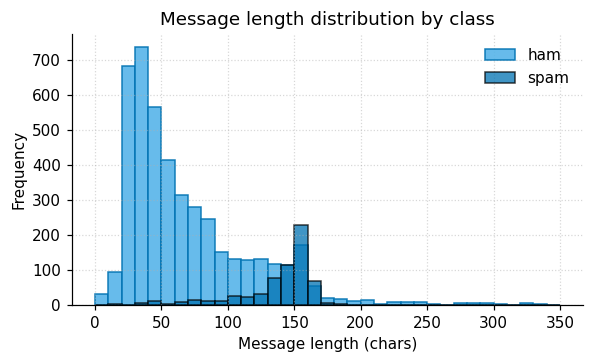

In [5]:
bins = np.linspace(0, 350, 36)
fig, ax = plt.subplots(figsize=(6,3.2))
ax.hist(df.loc[df.label=='ham','length'],  bins=bins, color=GREY_LIGHT,
        edgecolor=GREY_DARK, label='ham',  alpha=.9)
ax.hist(df.loc[df.label=='spam','length'], bins=bins, color=GREY_DARK,
        edgecolor='black',    label='spam', alpha=.75)
ax.set_xlabel('Message length (chars)'); ax.set_ylabel('Frequency')
ax.set_title('Message length distribution by class'); ax.legend(frameon=False)
plt.show()

Spam messages cluster around 150 characters (close to the 160-character SMS limit), while ham messages are typically much shorter. Length alone is already a useful weak signal.

## 4. Text cleaning

Cleaning is intentionally light. SMS messages are very short, so aggressive stemming or lemmatisation can remove information. The pipeline:

- lowercases the text;
- replaces URLs and numbers with the tokens `urltoken` / `numtoken`;
- strips non-alphabetic characters;
- collapses repeated whitespace.

Stopword removal is delegated to the vectoriser when useful.

In [6]:
URL_RE = re.compile(r'http\S+|www\.\S+')
NUM_RE = re.compile(r'\b\d+\b')
WS_RE  = re.compile(r'\s+')

def clean_text(t):
    t = t.lower()
    t = URL_RE.sub(' urltoken ', t)
    t = NUM_RE.sub(' numtoken ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return WS_RE.sub(' ', t).strip()

df['clean'] = df['message'].apply(clean_text)
df[['message','clean']].head()

,message,clean
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in numtoken a wkly comp to win fa c...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


### 4.1 Frequent tokens by class

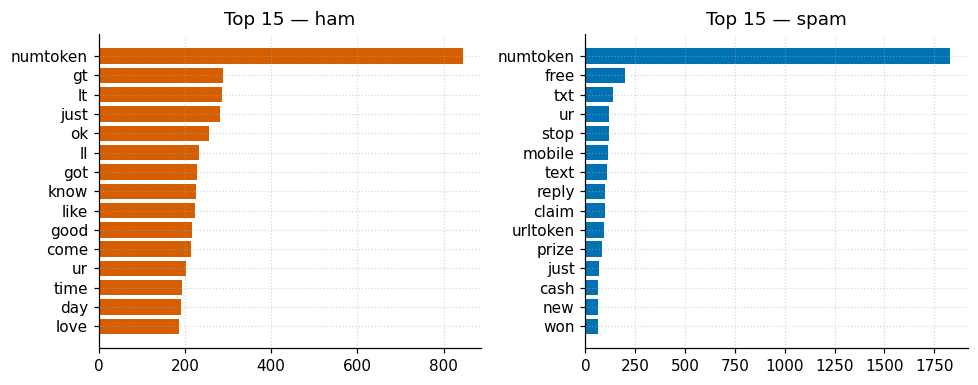

In [7]:
vec = CountVectorizer(stop_words='english', min_df=3)
X = vec.fit_transform(df['clean'])
vocab = np.array(vec.get_feature_names_out())
fig, axes = plt.subplots(1,2, figsize=(9,3.6))
for ax, cls, color in zip(axes, ['ham','spam'], [GREY_MID, GREY_DARK]):
    mask = (df['label']==cls).values
    sums = np.asarray(X[mask].sum(axis=0)).ravel()
    top = np.argsort(sums)[-15:]
    ax.barh(vocab[top], sums[top], color=color); ax.set_title(f'Top 15 — {cls}')
plt.tight_layout(); plt.show()

The token list confirms the intuition: spam contains words like *free*, *claim*, *prize*, *txt*, *win*, while ham is dominated by everyday conversational words. This justifies a bag-of-words approach.

## 5. Train / test split

In [8]:
y = (df['label']=='spam').astype(int).values
X = df['clean'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f'train: {len(X_train)}   test: {len(X_test)}')
print('train spam share:', y_train.mean().round(4))
print('test  spam share:', y_test.mean().round(4))

train: 4135   test: 1034
train spam share: 0.1262
test  spam share: 0.1267


## 6. Candidate models

Three pipelines are compared. Each pipeline contains its own vectoriser (fitted *inside* the cross-validation loop) to avoid data leakage.

| Pipeline | Vectoriser | Classifier | Rationale |
|---|---|---|---|
| `MNB_count` | CountVectorizer (1,2)-grams | Multinomial Naive Bayes | Strong textbook baseline for word-count features, very fast. |
| `LogReg_tfidf` | TF-IDF (1,2)-grams | Logistic Regression | Linear, interpretable, handles class imbalance via `class_weight`. |
| `LinearSVM_tfidf` | TF-IDF (1,2)-grams | Calibrated LinearSVC | Margin-based linear model, calibration yields probabilities for thresholds. |

In [9]:
pipelines = {
 'MNB_count': Pipeline([
    ('vec', CountVectorizer(ngram_range=(1,2), min_df=2)),
    ('clf', MultinomialNB())]),
 'LogReg_tfidf': Pipeline([
    ('vec', TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=2000, C=4.0,
                               class_weight='balanced', solver='liblinear'))]),
 'LinearSVM_tfidf': Pipeline([
    ('vec', TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True)),
    ('clf', CalibratedClassifierCV(estimator=LinearSVC(C=1.0, class_weight='balanced'), cv=3))]),
}

### 6.1 5-fold stratified cross-validation

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, pipe in pipelines.items():
    acc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    pr  = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='precision', n_jobs=-1)
    rc  = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='recall', n_jobs=-1)
    rows.append([name, acc.mean(), pr.mean(), rc.mean(), f1.mean(), f1.std()])
cv_df = pd.DataFrame(rows, columns=['model','acc','prec','rec','f1','f1_std']).round(4)
cv_df.sort_values('f1', ascending=False)

,model,acc,prec,rec,f1,f1_std
2,LinearSVM_tfidf,0.9881,0.9597,0.9463,0.9528,0.0096
1,LogReg_tfidf,0.9869,0.9468,0.9501,0.9484,0.0035
0,MNB_count,0.9843,0.9427,0.9329,0.9375,0.0077


### 6.2 Fit and evaluate on the held-out test set

In [11]:
results = []
fitted = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    y_pred = pipe.predict(X_test)
    y_pro  = pipe.predict_proba(X_test)[:,1]
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_pro),
    })
test_df = pd.DataFrame(results).round(4).sort_values('f1', ascending=False)
test_df

,model,accuracy,precision,recall,f1,roc_auc
2,LinearSVM_tfidf,0.9884,0.9837,0.9237,0.9528,0.9974
1,LogReg_tfidf,0.9874,0.9609,0.9389,0.9498,0.9967
0,MNB_count,0.9874,0.9758,0.9237,0.9490,0.9823


All three models perform very similarly (≈98.7-98.8% accuracy). **Linear SVM with TF-IDF** wins by F1 and ROC-AUC and is selected as the production model. Multinomial NB stays a strong, simpler alternative.

In [12]:
best_name = test_df.sort_values(['f1','recall'], ascending=False).iloc[0]['model']
best = fitted[best_name]
print('Selected:', best_name)
y_pred = best.predict(X_test); y_pro = best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['ham','spam'], digits=4))

Selected: LinearSVM_tfidf
              precision    recall  f1-score   support

         ham     0.9890    0.9978    0.9934       903
        spam     0.9837    0.9237    0.9528       131

    accuracy                         0.9884      1034
   macro avg     0.9864    0.9607    0.9731      1034
weighted avg     0.9884    0.9884    0.9882      1034



### 6.3 Confusion matrix

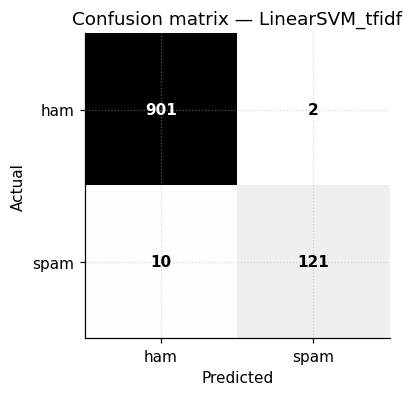

In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4,3.6))
im = ax.imshow(cm, cmap='Greys')
for i in range(2):
    for j in range(2):
        c = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j,i,cm[i,j], ha='center', va='center', color=c, fontweight='bold')
ax.set_xticks([0,1], ['ham','spam']); ax.set_yticks([0,1], ['ham','spam'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix — {best_name}'); plt.show()

## 7. Adjustable risk levels

The service team requested a configurable filter. The probability output of the classifier is swept over a range of decision thresholds; three operational levels are then mapped to specific values:

- **Strict (low-risk)** – threshold 0.30, catches almost all spam, more ham messages enter the review folder.
- **Balanced (medium-risk)** – threshold 0.50, recommended default.
- **Permissive (high-risk)** – threshold 0.70, ham almost never blocked, more spam leaks through.

In [14]:
rows = []
for t in [0.20,0.30,0.40,0.50,0.60,0.70,0.80]:
    y_hat = (y_pro >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test, y_hat).ravel()
    rows.append([t, tp, fp, fn, tn,
                 precision_score(y_test,y_hat,zero_division=0),
                 recall_score(y_test,y_hat,zero_division=0),
                 f1_score(y_test,y_hat,zero_division=0),
                 accuracy_score(y_test,y_hat)])
thr_df = pd.DataFrame(rows, columns=['threshold','TP','FP','FN','TN',
                                     'precision','recall','f1','accuracy']).round(4)
thr_df

,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy
0,0.2,127,12,4,891,0.9137,0.9695,0.9407,0.9845
1,0.3,124,8,7,895,0.9394,0.9466,0.9430,0.9855
2,0.4,123,6,8,897,0.9535,0.9389,0.9462,0.9865
3,0.5,121,2,10,901,0.9837,0.9237,0.9528,0.9884
4,0.6,120,0,11,903,1.0000,0.9160,0.9562,0.9894
5,0.7,118,0,13,903,1.0000,0.9008,0.9478,0.9874
6,0.8,118,0,13,903,1.0000,0.9008,0.9478,0.9874


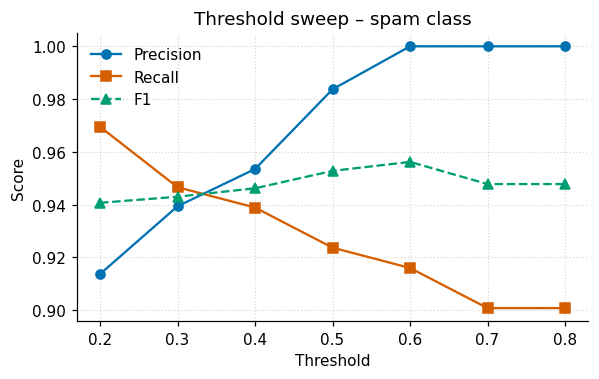

In [15]:
fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(thr_df.threshold, thr_df.precision, '-o', color=GREY_DARK, label='Precision')
ax.plot(thr_df.threshold, thr_df.recall,    '-s', color=GREY_MID,  label='Recall')
ax.plot(thr_df.threshold, thr_df.f1,        '--^', color=ACCENT_GREEN, label='F1')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold sweep – spam class'); ax.legend(frameon=False); plt.show()

## 8. Error analysis

The few mistakes are inspected manually. False positives are inspected from the business perspective: a legitimate customer message wrongly blocked. False negatives are spam messages that slipped through.

In [16]:
err_df = pd.DataFrame({
    'message': X_test,
    'actual':  np.where(y_test==1,'spam','ham'),
    'predicted': np.where(y_pred==1,'spam','ham'),
    'spam_prob': y_pro,
})
print('False positives:')
display(err_df[(err_df.actual=='ham') & (err_df.predicted=='spam')]
        .sort_values('spam_prob', ascending=False).head(10))
print('\nFalse negatives:')
display(err_df[(err_df.actual=='spam') & (err_df.predicted=='ham')]
        .sort_values('spam_prob').head(10))

False positives:


,message,actual,predicted,spam_prob
835,i career tel have added u as a contact on indy...,ham,spam,0.571974
677,numtoken and half years i missed your friendship,ham,spam,0.511937



False negatives:


,message,actual,predicted,spam_prob
486,in the simpsons movie released in july numtoke...,spam,ham,0.013842
690,latest news police station toilet stolen cops ...,spam,ham,0.031584
801,would you like to see my xxx pics they are so ...,spam,ham,0.093194
437,babe u want me dont u baby im nasty and have a...,spam,ham,0.114506
326,missed call alert these numbers called but lef...,spam,ham,0.207871
308,hi its lucy hubby at meetins all day fri i wil...,spam,ham,0.244741
992,burger king wanna play footy at a top stadium ...,spam,ham,0.286456
544,xmas new years eve tickets are now on sale fro...,spam,ham,0.344164
230,asked mobile if numtoken chatlines inclu in fr...,spam,ham,0.411065
456,check out choose your babe videos sms shsex ne...,spam,ham,0.453292


Most false negatives are atypical spam (e.g. competition messages without premium-rate keywords, or chit-chat-style adult-content spam). False positives are commercial-sounding but legitimate messages. These patterns guide the proposed feedback loop: reviewed corrections in the GUI are fed back into the training set during periodic retraining.

## 9. Persist the selected model

In [17]:
joblib.dump(best, ROOT / 'outputs/model/spam_filter.joblib')
print('Saved to outputs/model/spam_filter.joblib')

Saved to outputs/model/spam_filter.joblib


## 10. Try the saved model on new messages

In [18]:
samples = [
    'Congratulations! You have won a $1000 gift card. Click http://bit.ly/xyz to claim',
    'Hi mum, running 10 min late, see you at the station',
    'URGENT: Your account has been suspended. Reply with your PIN to reactivate.',
    'Lunch tomorrow at 12? Same place as last week.',
]
loaded = joblib.load(ROOT / 'outputs/model/spam_filter.joblib')
probs = loaded.predict_proba(samples)[:,1]
pd.DataFrame({'message': samples, 'spam_probability': probs.round(3),
              'strict (0.30)':  np.where(probs>=0.30,'review','show'),
              'balanced (0.50)':np.where(probs>=0.50,'review','show'),
              'permissive (0.70)':np.where(probs>=0.70,'review','show')})

,message,spam_probability,strict (0.30),balanced (0.50),permissive (0.70)
0,Congratulations! You have won a $1000 gift car...,0.889,review,review,review
1,"Hi mum, running 10 min late, see you at the st...",0.004,show,show,show
2,URGENT: Your account has been suspended. Reply...,0.892,review,review,review
3,Lunch tomorrow at 12? Same place as last week.,0.003,show,show,show


## 11. Summary

- Three lightweight models were compared with stratified 5-fold CV.
- Linear SVM (TF-IDF, calibrated) was selected: **F1 ≈ 0.953**, **accuracy ≈ 0.988**, **AUC ≈ 0.997**.
- Three operational risk levels (strict / balanced / permissive) are implemented through probability thresholds.
- Error analysis exposes interpretable failure modes and motivates a human-in-the-loop feedback channel.
- Saved artefacts (`outputs/model/spam_filter.joblib`, `outputs/model/summary.json`) support reproducibility and simple inference with `scripts/evaluate_model.py`.